In [ ]:
# %pip install torch librosa transformers chromadb scikit-learn

In [ ]:
import torch
import librosa
import numpy as np
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import chromadb
from chromadb.config import Settings
from sklearn.metrics.pairwise import cosine_similarity

# Load pre-trained Wav2Vec2 model and processor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

# Settings
AUDIO_DIR = r"C:\genai\Audio"
SAMPLE_RATE = 16000
COLLECTION_NAME = r"audio_embeddings_wav2Vec22"

# Function to extract audio embeddings
def extract_embedding(audio_path):
    waveform, sr = librosa.load(audio_path, sr=16000)
    inputs = processor(waveform, sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    return embedding




def init_chroma_collection():
    # Initialize ChromaDB in-memory client
    client = chromadb.Client(Settings(anonymized_telemetry=False))

    # List all collections
    collections = chroma_client.list_collections()

    # Delete each collection
    for collection in collections:
        chroma_client.delete_collection(name=collection.name)

    if COLLECTION_NAME not in [col.name for col in client.list_collections()]:
        collection = client.create_collection(name=COLLECTION_NAME)
    else:
        collection = client.get_collection(name=COLLECTION_NAME)
    return collection


# Function to compute similarity between two audio files
def compare_audio_files(file1, file2):
    emb1 = extract_embedding(file1)
    emb2 = extract_embedding(file2)
    
    collection = init_chroma_collection()
    # Store embeddings in ChromaDB
    collection.add(documents=["audio1"], embeddings=[emb1.tolist()], ids=["1"])
    collection.add(documents=["audio2"], embeddings=[emb2.tolist()], ids=["2"])
    

    # Compute cosine similarity
    similarity = cosine_similarity([emb1], [emb2])[0][0]
    return similarity

# Example usage
file_path_1 = r"C:\genai\Audio\lofi-163236.wav"
file_path_2 = r"C:\genai\Audio\comedy-music-theme-121124.wav"

similarity_score = compare_audio_files(file_path_1, file_path_2 )
print(f"Similarity score between the two audio files: {similarity_score:.4f}")


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Similarity score between the two audio files: 0.9417


In [ ]:
# pip install torch librosa transformers scikit-learn matplotlib


 ### What is Wav2Vec2Processor?
It’s a preprocessing and postprocessing utility that combines two tools:

Feature extractor – Converts raw audio waveforms into input features suitable for the model.<br>
Tokenizer – Converts model outputs (like logits) into human-readable text (for ASR tasks).

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Processing C:\genai\Audio\abc-song-loop-119706.wav...
Loading audio file: C:\genai\Audio\abc-song-loop-119706.wav
Processing C:\genai\Audio\astral-creepy-dark-logo-254198.wav...
Loading audio file: C:\genai\Audio\astral-creepy-dark-logo-254198.wav
Processing C:\genai\Audio\chill-song-197193.wav...
Loading audio file: C:\genai\Audio\chill-song-197193.wav
Processing C:\genai\Audio\comedy-music-theme-121124.wav...
Loading audio file: C:\genai\Audio\comedy-music-theme-121124.wav
Processing C:\genai\Audio\dont-talk-315229.wav...
Loading audio file: C:\genai\Audio\dont-talk-315229.wav
Processing C:\genai\Audio\future-design-344320.wav...
Loading audio file: C:\genai\Audio\future-design-344320.wav
Processing C:\genai\Audio\indian-bansuri-tabla-fusion-short-music-25-seconds-track-269954.wav...
Loading audio file: C:\genai\Audio\indian-bansuri-tabla-fusion-short-music-25-seconds-track-269954.wav
Processing C:\genai\Audio\indian-bansuri-tabla-fusion-short.wav...
Loading audio file: C:\genai\Audi

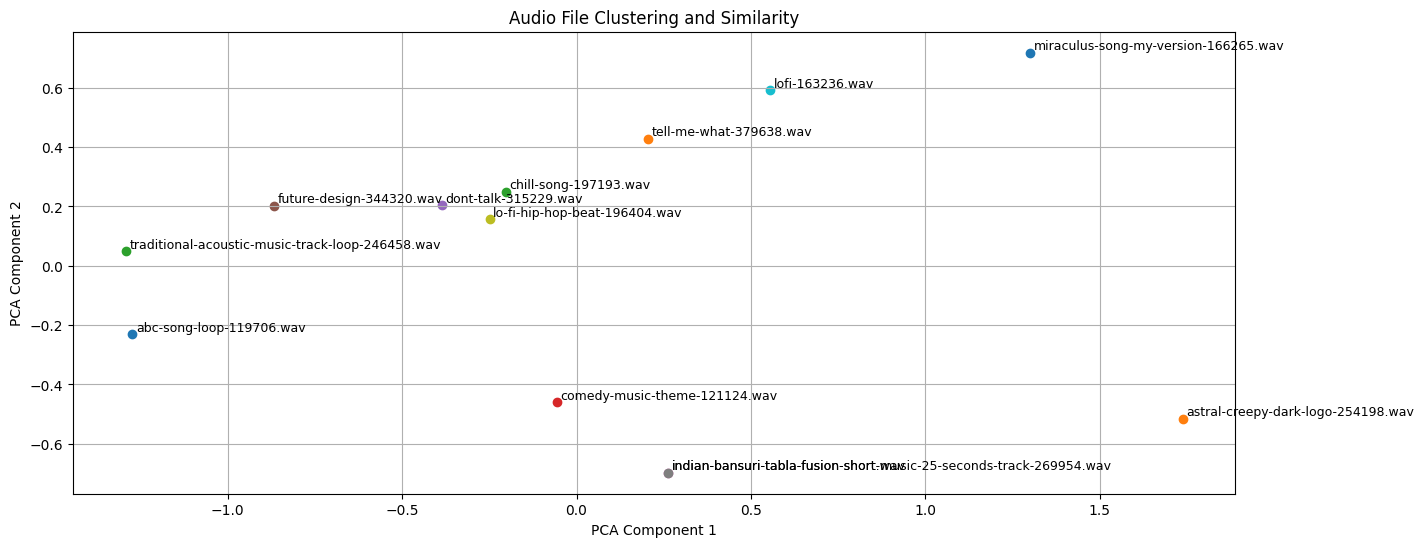

In [40]:

import os
import torch
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from transformers import Wav2Vec2Processor, Wav2Vec2Model

# Load Wav2Vec2 model and processor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

# Function to extract embedding from audio file
def extract_embedding(audio_path):
    print(f"Loading audio file: {audio_path}")
    waveform, sr = librosa.load(audio_path, sr=16000)
    inputs = processor(waveform, sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    return embedding

# Load all .wav files in the current directory
audio_files = [os.path.join(AUDIO_DIR, f)    for f in os.listdir(r'C:\genai\Audio') if f.endswith('.wav')]
embeddings = []
file_names = []

for file in audio_files:
    print(f"Processing {file}...")
    emb = extract_embedding(file)
    embeddings.append(emb)
    file_names.append(file)

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Print similarity matrix
# print("\nCosine Similarity Matrix:")
# print(similarity_matrix)

# Perform KMeans clustering
num_clusters = min(3, len(embeddings))  # Use 3 or fewer clusters if fewer files
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
labels = kmeans.fit_predict(embeddings)

# Reduce dimensions for visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# Plot the results
plt.figure(figsize=(15, 6))
for i, cluster_label in enumerate(labels):
    short_label = file_names[i].replace("C:\\genai\\Audio\\", "")
    plt.scatter(reduced[i, 0], reduced[i, 1], label=f"{short_label} (Cluster {cluster_label})")
    plt.text(reduced[i, 0]+0.01, reduced[i, 1]+0.01, short_label, fontsize=9)
plt.title("Audio File Clustering and Similarity")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()
